In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

df = pd.read_csv("data.csv")
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

C:\Users\aceec\AppData\Local\Temp\ipykernel_7748\3247936119.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Benign (B)', 'Malignant (M)'])


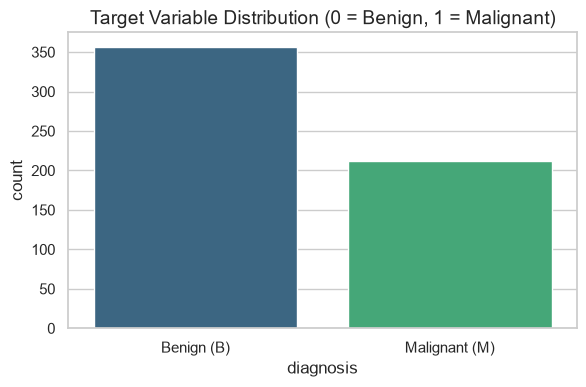

In [2]:
cols_to_drop = [col for col in ['id', 'Unnamed: 32'] if col in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='viridis', legend=False)
plt.title('Target Variable Distribution (0 = Benign, 1 = Malignant)')
ax.set_xticklabels(['Benign (B)', 'Malignant (M)'])
plt.tight_layout()
plt.show()

In [3]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training features: {X_train.shape[0]} samples")
print(f"Testing features: {X_test.shape[0]} samples")

Training features: 455 samples
Testing features: 114 samples


In [4]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
clf.fit(X_train, y_train);

Model Accuracy: 90.3509%

               precision    recall  f1-score   support

   Benign (0)       0.90      0.96      0.93        72
Malignant (1)       0.92      0.81      0.86        42

     accuracy                           0.90       114
    macro avg       0.91      0.88      0.89       114
 weighted avg       0.90      0.90      0.90       114



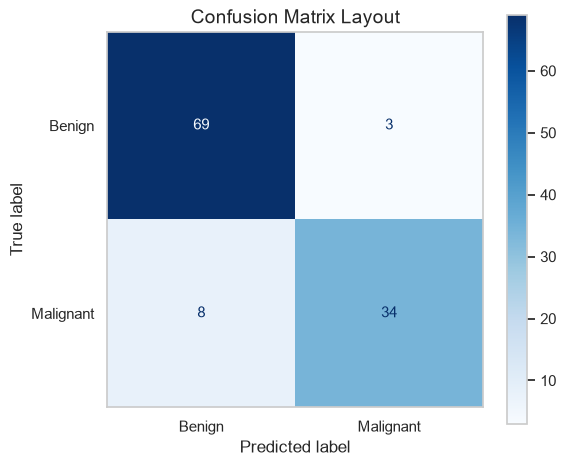

In [5]:
y_pred = clf.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4%}\n")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Benign', 'Malignant'], cmap='Blues', ax=ax
)
plt.title("Confusion Matrix Layout")
plt.grid(False)
plt.tight_layout()
plt.show()

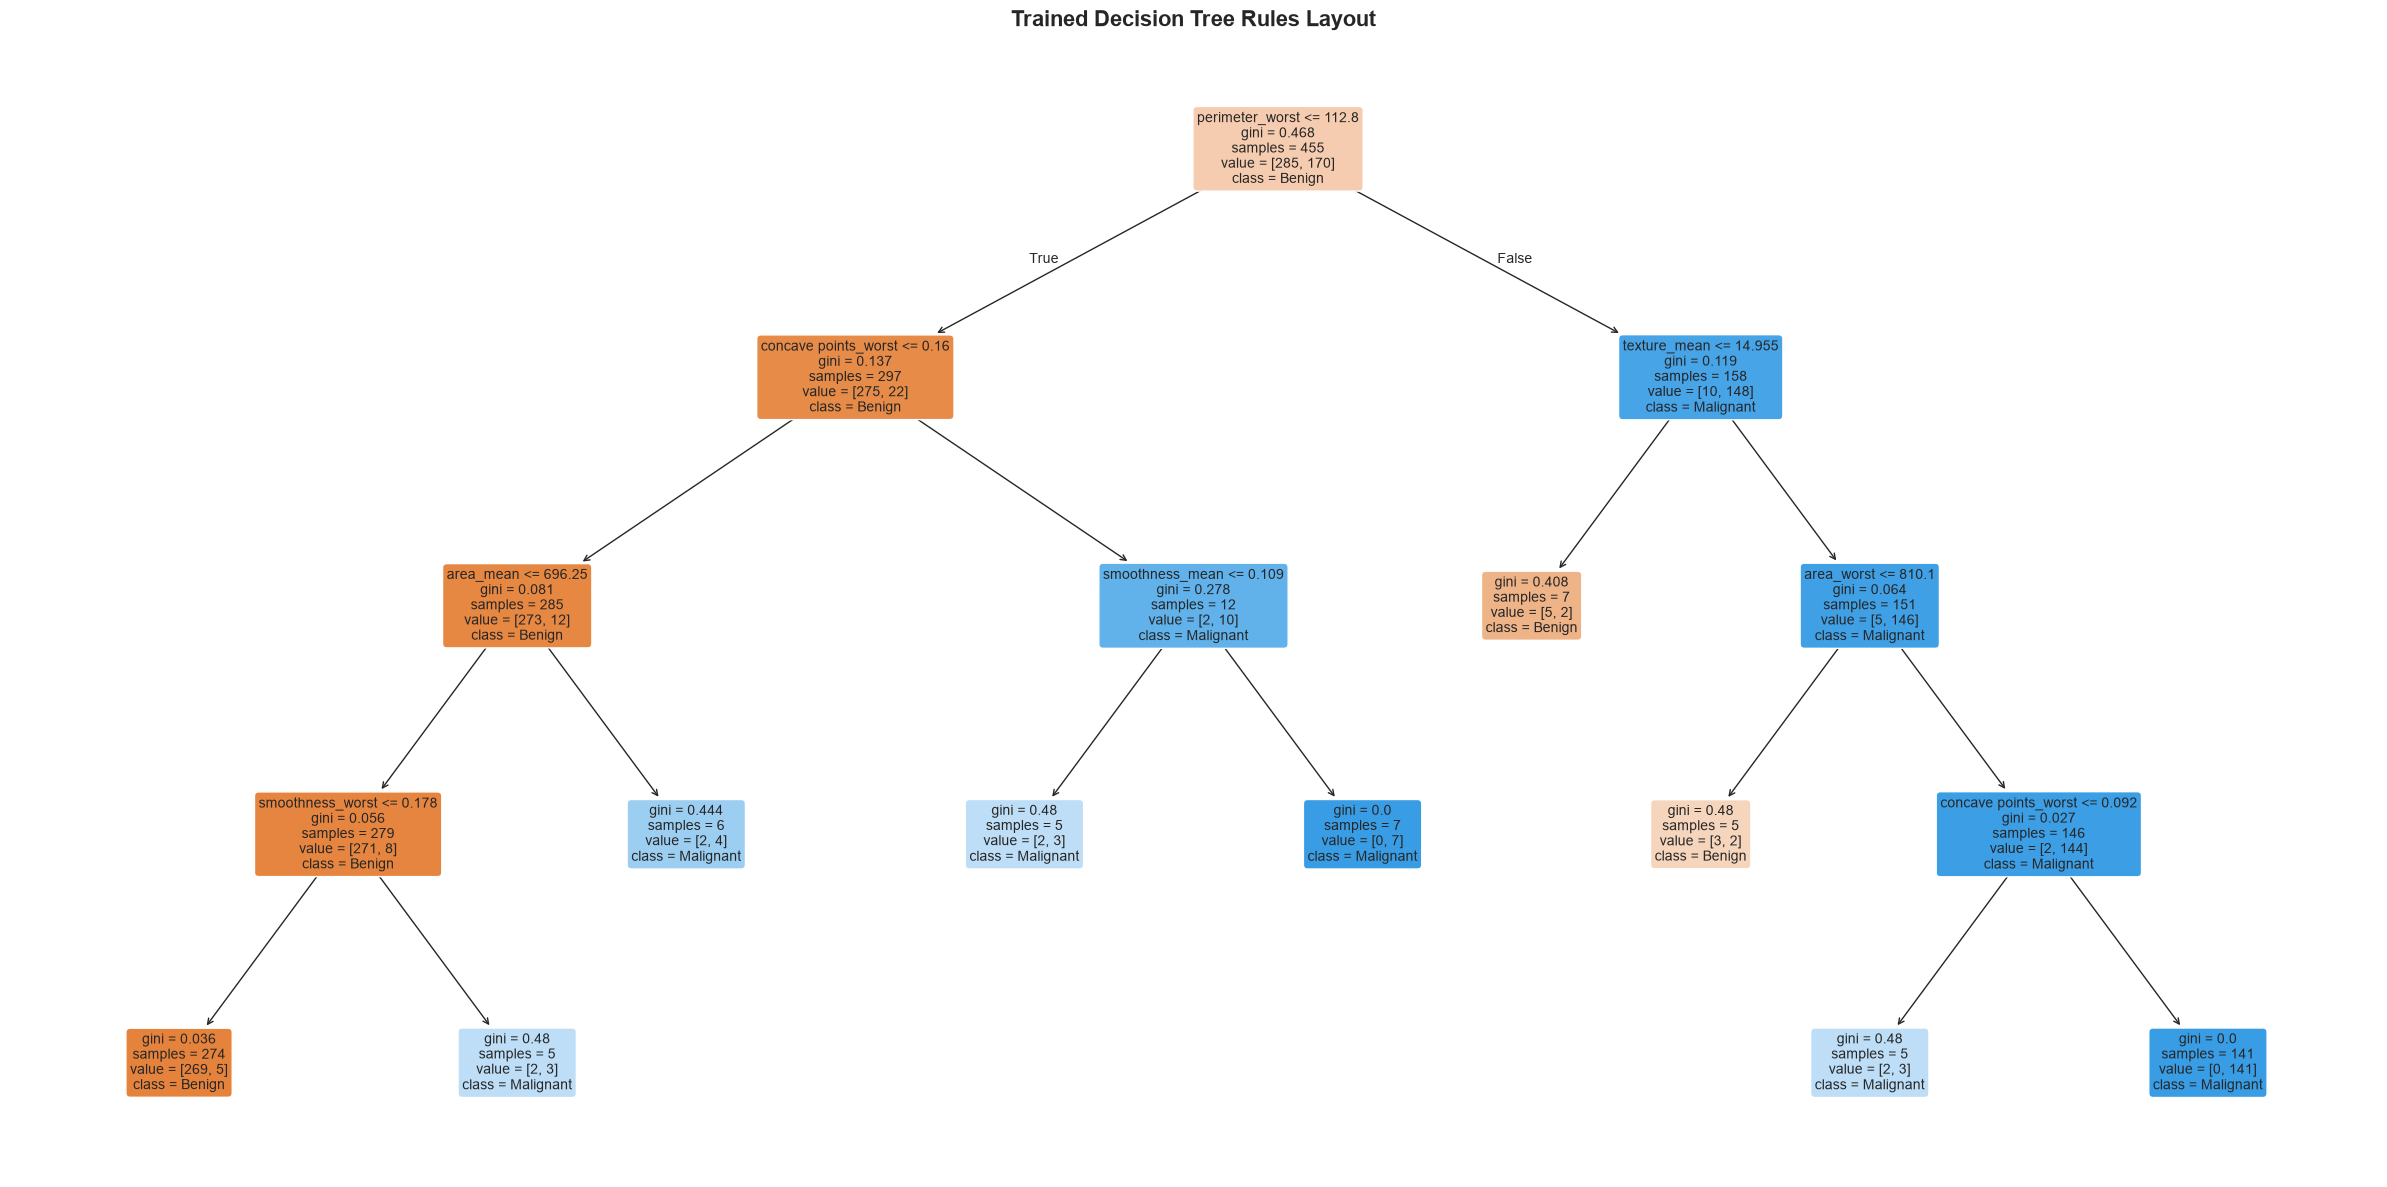

In [6]:
plt.figure(figsize=(24, 12))
plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=['Benign', 'Malignant'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Trained Decision Tree Rules Layout", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\aceec\AppData\Local\Temp\ipykernel_7748\3643150179.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


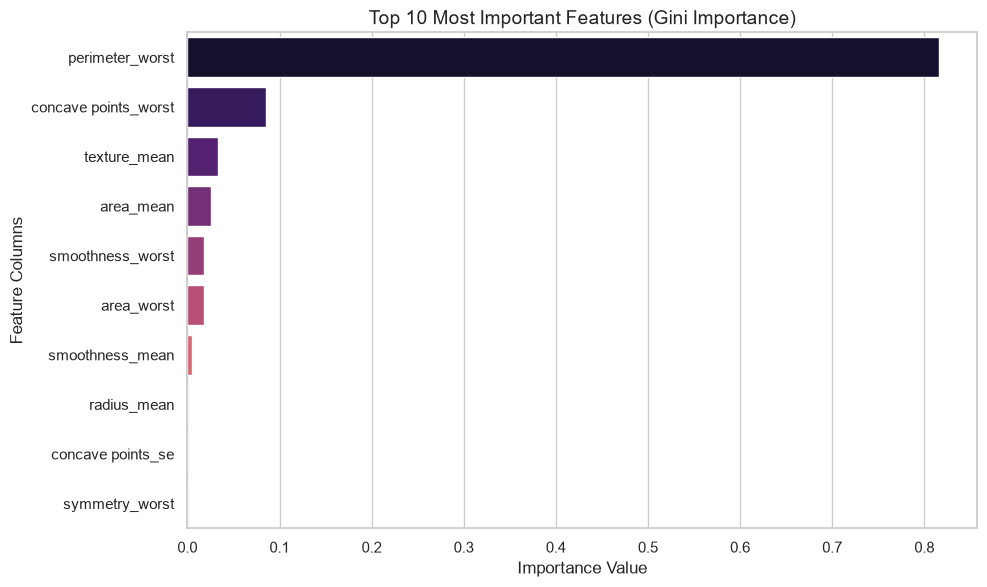

             Feature  Importance
     perimeter_worst    0.816336
concave points_worst    0.084899
        texture_mean    0.033018
           area_mean    0.025431
    smoothness_worst    0.017677
          area_worst    0.017677
     smoothness_mean    0.004964
         radius_mean    0.000000
   concave points_se    0.000000
      symmetry_worst    0.000000


In [7]:
importances = clf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 10 Most Important Features (Gini Importance)')
plt.xlabel('Importance Value')
plt.ylabel('Feature Columns')
plt.tight_layout()
plt.show()

print(feature_importance_df.to_string(index=False))